In [1]:
import pandas as pd 
df1 = pd.read_csv("D:\GUVI\PROJECTS\Final project\data\customer_churn_sentiment_dataset.csv")
df1.head()

<>:2: SyntaxWarning: invalid escape sequence '\G'
<>:2: SyntaxWarning: invalid escape sequence '\G'
C:\Users\Admin\AppData\Local\Temp\ipykernel_43960\1282960254.py:2: SyntaxWarning: invalid escape sequence '\G'
  df1 = pd.read_csv("D:\GUVI\PROJECTS\Final project\data\customer_churn_sentiment_dataset.csv")


,CustomerID,Gender,Age,SubscriptionType,TenureMonths,MonthlyUsageHours,LastInteractionChannel,FeedbackText,SentimentLabel,Churn,Churn_L
0,C0001,Male,37,Premium,15,20,App,Very convenient and reliable service!,Positive,0,Continue
1,C0002,Female,52,Standard,12,33,Call,Service quality fluctuates sometimes.,Neutral,1,Leave
2,C0003,Female,25,Basic,22,9,Chat,"App works fine, nothing special to mention.",Neutral,0,Continue
3,C0004,Male,57,Standard,4,26,Email,"Fantastic experience, highly recommend!",Positive,0,Continue
4,C0005,Male,46,Premium,3,25,Email,"Smooth experience overall, everything works well.",Positive,0,Continue


In [2]:
df1.columns

Index(['CustomerID', 'Gender', 'Age', 'SubscriptionType', 'TenureMonths',
       'MonthlyUsageHours', 'LastInteractionChannel', 'FeedbackText',
       'SentimentLabel', 'Churn', 'Churn_L'],
      dtype='object')

In [3]:
df1.shape

(3000, 11)

In [4]:
df1.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
SubscriptionType          0
TenureMonths              0
MonthlyUsageHours         0
LastInteractionChannel    0
FeedbackText              0
SentimentLabel            0
Churn                     0
Churn_L                   0
dtype: int64

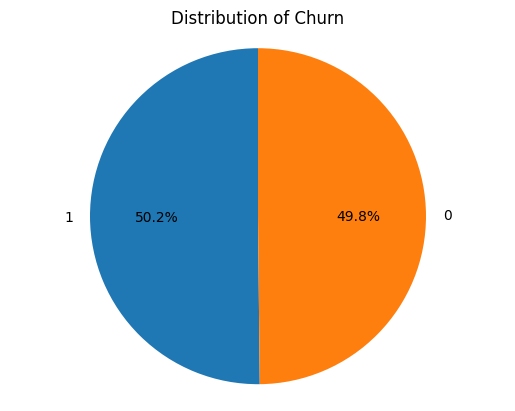

In [5]:
#pie chart
import matplotlib.pyplot as plt 
labels = df1['Churn'].value_counts().index
sizes = df1['Churn'].value_counts().values
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.axis('equal')   
plt.title('Distribution of Churn')
plt.show()

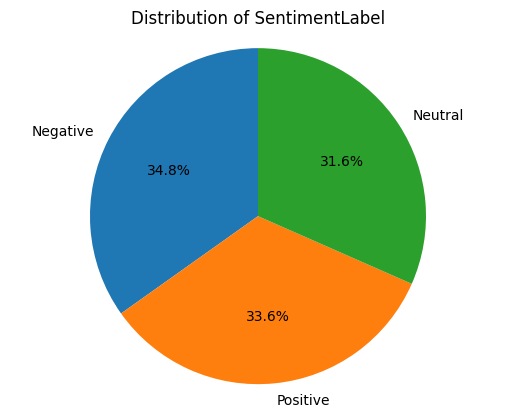

In [6]:
#pie chart
import matplotlib.pyplot as plt 
labels = df1['SentimentLabel'].value_counts().index
sizes = df1['SentimentLabel'].value_counts().values
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.title('Distribution of SentimentLabel')
plt.show()

In [7]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt_tab')

stop_words = set(stopwords.words("english"))
negation_words = {"not", "no", "never"}
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [8]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)       # remove punctuation
    words = nltk.word_tokenize(text)

    cleaned = []
    for w in words:
        if w in negation_words:
            cleaned.append(w)
        elif w not in stop_words:
            cleaned.append(lemmatizer.lemmatize(w))
    return " ".join(cleaned)

df = df1[['FeedbackText','SentimentLabel']]
df['Cleaned_Feedback'] = df['FeedbackText'].apply(clean_text)
df.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_43960\3306202440.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Cleaned_Feedback'] = df['FeedbackText'].apply(clean_text)


,FeedbackText,SentimentLabel,Cleaned_Feedback
0,Very convenient and reliable service!,Positive,convenient reliable service
1,Service quality fluctuates sometimes.,Neutral,service quality fluctuates sometimes
2,"App works fine, nothing special to mention.",Neutral,app work fine nothing special mention
3,"Fantastic experience, highly recommend!",Positive,fantastic experience highly recommend
4,"Smooth experience overall, everything works well.",Positive,smooth experience overall everything work well


In [9]:
df.tail()

,FeedbackText,SentimentLabel,Cleaned_Feedback
2995,"Billing issues every month, not satisfied.",Negative,billing issue every month not satisfied
2996,"Not worth the money, disappointed.",Negative,not worth money disappointed
2997,"Not bad, but not exceptional either.",Neutral,not bad not exceptional either
2998,"Support is unresponsive, very frustrating.",Negative,support unresponsive frustrating
2999,"It's okay, but could use more features.",Neutral,okay could use feature


In [10]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['label'] = encoder.fit_transform(df['SentimentLabel'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_43960\653751024.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label'] = encoder.fit_transform(df['SentimentLabel'])


In [11]:
display(df.head())

,FeedbackText,SentimentLabel,Cleaned_Feedback,label
0,Very convenient and reliable service!,Positive,convenient reliable service,2
1,Service quality fluctuates sometimes.,Neutral,service quality fluctuates sometimes,1
2,"App works fine, nothing special to mention.",Neutral,app work fine nothing special mention,1
3,"Fantastic experience, highly recommend!",Positive,fantastic experience highly recommend,2
4,"Smooth experience overall, everything works well.",Positive,smooth experience overall everything work well,2


In [12]:
from collections import Counter
import torch

MAX_VOCAB = 100
MAX_LEN = 20

# Tokenize
def tokenize(sentence):
    return sentence.split()

# Build vocabulary
counter = Counter()
for text in df['Cleaned_Feedback']:
    counter.update(tokenize(text))

most_common = counter.most_common(MAX_VOCAB - 2)

# Indexes:
# 0 = PAD
# 1 = OOV
word2idx = {"<PAD>": 0, "<OOV>": 1}
for idx, (word, _) in enumerate(most_common, start=2):
    word2idx[word] = idx

In [13]:
print(word2idx)

{'<PAD>': 0, '<OOV>': 1, 'service': 2, 'support': 3, 'experience': 4, 'not': 5, 'satisfied': 6, 'quality': 7, 'money': 8, 'issue': 9, 'highly': 10, 'quick': 11, 'app': 12, 'customer': 13, 'improvement': 14, 'work': 15, 'overall': 16, 'okay': 17, 'sometimes': 18, 'great': 19, 'could': 20, 'feature': 21, 'worth': 22, 'disappointed': 23, 'im': 24, 'tired': 25, 'constant': 26, 'planning': 27, 'cancel': 28, 'soon': 29, 'excellent': 30, 'totally': 31, 'topnotch': 32, 'decent': 33, 'room': 34, 'many': 35, 'interruption': 36, 'no': 37, 'keep': 38, 'disconnecting': 39, 'unacceptable': 40, 'fantastic': 41, 'recommend': 42, 'lag': 43, 'billing': 44, 'every': 45, 'month': 46, 'fine': 47, 'nothing': 48, 'special': 49, 'mention': 50, 'team': 51, 'efficient': 52, 'happy': 53, 'good': 54, 'slow': 55, 'unresponsive': 56, 'frustrating': 57, 'smooth': 58, 'everything': 59, 'well': 60, 'value': 61, 'really': 62, 'impressed': 63, 'average': 64, 'better': 65, 'convenient': 66, 'reliable': 67, 'take': 68, 'f

In [14]:
def encode_text(text):
    tokens = tokenize(text)
    seq = [word2idx.get(w, 1) for w in tokens]  # 1 = OOV
    # pad or truncate
    if len(seq) < MAX_LEN:
        seq = seq + [0] * (MAX_LEN - len(seq))
    else:
        seq = seq[:MAX_LEN]
    return torch.tensor(seq)

In [15]:
X = torch.stack(df['Cleaned_Feedback'].apply(encode_text).tolist())
y = torch.tensor(df['label'].values)

In [16]:
from torch.utils.data import Dataset, DataLoader

class FeedbackDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = FeedbackDataset(X, y)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [17]:
#model building
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256,
                 num_classes=3, num_layers=2, dropout=0.5, padding_idx=0):
        super().__init__()

        self.embedding     = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        self.embed_dropout = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers    = num_layers,
            batch_first   = True,
            dropout       = dropout if num_layers > 1 else 0.0,  # ✅ dropout only between layers
            bidirectional = True
        )

        self.attention = nn.Linear(hidden_dim * 2, 1)

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(hidden_dim, num_classes)
        )

    def attention_pool(self, lstm_out):
        scores  = self.attention(lstm_out).squeeze(-1)   # (batch, seq_len)
        weights = torch.softmax(scores, dim=1)           # (batch, seq_len)
        pooled  = (lstm_out * weights.unsqueeze(-1)).sum(dim=1)  # (batch, hidden*2)
        return pooled

    def forward(self, x, lengths=None):
        # 1. Embed
        embedded = self.embed_dropout(self.embedding(x))  # (batch, seq, embed)

        # 2. Pack → LSTM → Unpack
        if lengths is not None:
            embedded = pack_padded_sequence(
                embedded, lengths.cpu(),
                batch_first=True, enforce_sorted=False
            )

        lstm_out, _ = self.lstm(embedded)                 # (batch, seq, hidden*2)

        if lengths is not None:
            lstm_out, _ = pad_packed_sequence(lstm_out, batch_first=True)

        # 3. Attention pool
        pooled = self.attention_pool(lstm_out)            # (batch, hidden*2)

        # 4. Classify — ✅ always returns a tensor
        return self.classifier(pooled)                    # (batch, num_classes)


# ── Re-instantiate cleanly ────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SentimentLSTM(
    vocab_size  = len(word2idx),
    embed_dim   = 128,
    hidden_dim  = 256,
    num_classes = 3,
    num_layers  = 2,
    dropout     = 0.5
).to(device)

# ── Sanity check before training ─────────────────────────────────────
dummy_input   = torch.zeros(2, 20, dtype=torch.long).to(device)
dummy_lengths = torch.tensor([20, 20])
out = model(dummy_input, dummy_lengths)

assert isinstance(out, torch.Tensor),    f"❌ forward() returned {type(out)}, expected Tensor"
assert out.shape == (2, 3),              f"❌ Wrong output shape: {out.shape}, expected (2, 3)"
assert not torch.isnan(out).any(),       "❌ NaN detected in output"

print("✅ Sanity check passed!")
print(f"   Output type : {type(out)}")
print(f"   Output shape: {out.shape}")   # torch.Size([2, 3])

✅ Sanity check passed!
   Output type : <class 'torch.Tensor'>
   Output shape: torch.Size([2, 3])


In [18]:
# ✅ Ensure model is your custom LSTM (run this before training)
model = SentimentLSTM(
    vocab_size   = len(word2idx),
    embed_dim    = 128,
    hidden_dim   = 256,
    num_classes  = 3,
    num_layers   = 2,
    dropout      = 0.5
).to(device)

# Quick sanity check — should print: <class '__main__.SentimentLSTM'>
print(type(model))

# Forward pass smoke test — should return torch.Tensor
dummy_input   = torch.zeros(2, 20, dtype=torch.long).to(device)
dummy_lengths = torch.tensor([20, 20])
out = model(dummy_input, dummy_lengths)
print(f"Output type : {type(out)}")     # <class 'torch.Tensor'>
print(f"Output shape: {out.shape}")     # torch.Size([2, 3])

<class '__main__.SentimentLSTM'>
Output type : <class 'torch.Tensor'>
Output shape: torch.Size([2, 3])


In [ ]:
#model training and evaluation

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

# ── Device Setup ──────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# ── Loss, Optimizer & Scheduler ───────────────────────────────────────
criterion = nn.CrossEntropyLoss()          # Add weight=class_weights if imbalanced

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,            # ✅ Fixed: was 0.1 (too high)
    weight_decay=1e-5   # L2 regularization
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.5  #, verbose=True
)

# ── Helper: compute sequence lengths (non-padding tokens) ─────────────
def get_lengths(batch_x, padding_idx=0):
    """Returns actual length of each sequence, ignoring padding."""
    lengths = (batch_x != padding_idx).sum(dim=1).cpu()
    lengths = lengths.clamp(min=1)   # Avoid 0-length sequences
    return lengths


Split → Train: 2100 | Val: 300 | Test: 600
Epoch 05/30 | Train Loss: 0.0036  Acc: 0.9990 | Val   Loss: 0.0000  Acc: 1.0000
Epoch 10/30 | Train Loss: 0.0000  Acc: 1.0000 | Val   Loss: 0.0000  Acc: 1.0000
Epoch 15/30 | Train Loss: 0.0000  Acc: 1.0000 | Val   Loss: 0.0000  Acc: 1.0000
Epoch 20/30 | Train Loss: 0.0000  Acc: 1.0000 | Val   Loss: 0.0000  Acc: 1.0000
Epoch 25/30 | Train Loss: 0.0000  Acc: 1.0000 | Val   Loss: 0.0000  Acc: 1.0000
Epoch 30/30 | Train Loss: 0.0001  Acc: 1.0000 | Val   Loss: 0.0000  Acc: 1.0000

✅ Restored best model (val_loss=0.0000)

Test Accuracy: 1.0000 (600/600)

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       200
     Neutral       1.00      1.00      1.00       183
    Positive       1.00      1.00      1.00       217

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

In [ ]:
# ── Train / Validation Split ──────────────────────────────────────────
num_samples = len(X)
assert num_samples >= 5, "Need at least 5 samples to split."

perm       = torch.randperm(num_samples)
test_size  = max(1, int(0.2 * num_samples))
val_size   = max(1, int(0.1 * num_samples))
train_size = num_samples - test_size - val_size

train_idx = perm[:train_size]
val_idx   = perm[train_size:train_size + val_size]
test_idx  = perm[train_size + val_size:]

X_train, y_train = X[train_idx], y[train_idx]
X_val,   y_val   = X[val_idx],   y[val_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val,   y_val),   batch_size=32, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test,  y_test),  batch_size=32, shuffle=False)

print(f"Split → Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")


In [ ]:
# ── Training Loop ─────────────────────────────────────────────────────
def run_epoch(model, loader, optimizer, criterion, device, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            lengths = get_lengths(batch_x)   # ✅ Proper padding-aware lengths

            if train:
                optimizer.zero_grad()

            logits = model(batch_x, lengths)
            loss   = criterion(logits, batch_y)

            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # ✅ Gradient clipping
                optimizer.step()

            preds       = torch.argmax(logits, dim=1)
            total_loss += loss.item()
            correct    += (preds == batch_y).sum().item()
            total      += batch_y.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total if total > 0 else 0.0
    return avg_loss, accuracy


epochs      = 30
best_val_loss = float('inf')
best_state    = None

for epoch in range(epochs):
    train_loss, train_acc = run_epoch(model, train_loader, optimizer, criterion, device, train=True)
    val_loss,   val_acc   = run_epoch(model, val_loader,   optimizer, criterion, device, train=False)

    scheduler.step(val_loss)   # ✅ Reduce LR on plateau
    # ✅ Save best model checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state    = {k: v.clone() for k, v in model.state_dict().items()}

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
            f"Val   Loss: {val_loss:.4f}  Acc: {val_acc:.4f}"
        )


In [ ]:
# Restore best weights
if best_state:
    model.load_state_dict(best_state)
    print(f"\n✅ Restored best model (val_loss={best_val_loss:.4f})")

# ── Full Evaluation on Test Set ───────────────────────────────────────
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        lengths = get_lengths(batch_x)
        logits  = model(batch_x, lengths)
        preds   = torch.argmax(logits, dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(batch_y.tolist())

test_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"\nTest Accuracy: {test_acc:.4f} ({sum(p==l for p,l in zip(all_preds,all_labels))}/{len(all_labels)})")


In [ ]:
# ✅ Detailed metrics (Precision, Recall, F1 per class)
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=encoder.classes_))

# ✅ Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

# ── Prediction Function ───────────────────────────────────────────────
def predict(text):
    model.eval()
    cleaned = clean_text(text)
    encoded = encode_text(cleaned).unsqueeze(0).to(device)   # (1, seq_len)
    lengths = get_lengths(encoded)

    with torch.no_grad():
        logits      = model(encoded, lengths)
        probs       = torch.softmax(logits, dim=1).squeeze()  # ✅ Confidence scores
        label_idx   = torch.argmax(probs).item()
        confidence  = probs[label_idx].item()

    label = encoder.inverse_transform([label_idx])[0]
    print(f"Prediction : {label}  (confidence: {confidence:.2%})")
    return label, confidence

In [20]:
# Example usage
predict("This product is absolutely amazing!")
predict("Terrible experience, would not recommend.")

Prediction : Negative  (confidence: 97.98%)
Prediction : Neutral  (confidence: 93.91%)


('Neutral', 0.9390731453895569)

In [21]:
import pickle, torch

torch.save(model.state_dict(), "model.pt")
pickle.dump(word2idx, open("word2idx.pkl", "wb"))
pickle.dump(encoder,  open("encoder.pkl",  "wb"))

In [22]:
import pickle, torch

torch.save({
    'model_state_dict' : model.state_dict(),
    'word2idx'         : word2idx,
    'encoder_classes'  : list(encoder.classes_),
}, 'cs_lstm_model.pth')

with open('lstmencoder.pickle', 'wb') as f:
    pickle.dump(encoder, f)